In [1]:
# ── Config ───────────────────────────────────────────────────
import os, numpy as np, tifffile
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
os.makedirs('output', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'axes.titlecolor': 'white',
    'text.color': 'white'
})

SOMA_VOXEL          = None   # (z,y,x) 수동 고정 or None = 자동 검출
SOMA_SIGMA          = 8.0    # soma score Gaussian sigma (voxels)
SOMA_SEARCH_RADIUS  = 80     # local Otsu 구체 반지름 (voxels)
SOMA_MAX_TUBULARITY = 0.25   # 이 값 이상의 tubularity 복셀은 소마에서 제외 (dendrite)
SOMA_OPEN_RADIUS_VX = 10      # morphological opening — 가지 stub 제거
SOMA_CLOSE_RADIUS_VX= 4      # morphological closing — 작은 구멍 메우기
SOMA_ERODE_RADIUS_VX= 4      # morphological erosion — 남은 stub 추가 제거

# Load
tub        = np.load('output/tubularity.npz')
T_combined = tub['T_combined']
I_OOF_raw  = tub['I_OOF_raw']   # tubularity 필터용: OOF만, soma≈0 유지
voxel_iso  = float(tub['voxel_iso'])
stack      = tifffile.imread('output/stack_preprocessed.tif').astype(np.float32)
print(f'Loaded: T_combined {T_combined.shape}  stack {stack.shape}  voxel_iso={voxel_iso:.4f} µm')

Loaded: T_combined (1064, 996, 990)  stack (1064, 996, 990)  voxel_iso=0.3420 µm


In [2]:
# ── Step 7 · Soma Detection ───────────────────────────────────
# soma_score = 밝고 tubularity 낮은 곳 (소마 특성: 고강도 + 비관형)
from scipy.ndimage import gaussian_filter

if SOMA_VOXEL is not None:
    soma_voxel = tuple(int(v) for v in SOMA_VOXEL)
    print(f'Soma pinned manually: {soma_voxel}')
else:
    stack_f32   = stack.astype(np.float32)
    stack_norm  = (stack_f32 - stack_f32.min()) / (stack_f32.max() - stack_f32.min() + 1e-6)
    soma_score  = stack_norm * (1.0 - T_combined)
    soma_smooth = gaussian_filter(soma_score.astype(np.float32), sigma=SOMA_SIGMA)
    soma_voxel  = tuple(int(v) for v in
                        np.unravel_index(soma_smooth.argmax(), soma_smooth.shape))
    print(f'Auto-detected soma voxel : {soma_voxel}')
    print(f'  soma_score  at peak    : {soma_score[soma_voxel]:.4f}')
    print(f'  T_combined  at peak    : {T_combined[soma_voxel]:.4f}')
    print(f'  stack_norm  at peak    : {stack_norm[soma_voxel]:.4f}')
    print(f'\nIf this looks wrong, set SOMA_VOXEL = {soma_voxel} in Config and adjust.')

Auto-detected soma voxel : (265, 467, 438)
  soma_score  at peak    : 0.4057
  T_combined  at peak    : 0.5943
  stack_norm  at peak    : 1.0000

If this looks wrong, set SOMA_VOXEL = (265, 467, 438) in Config and adjust.


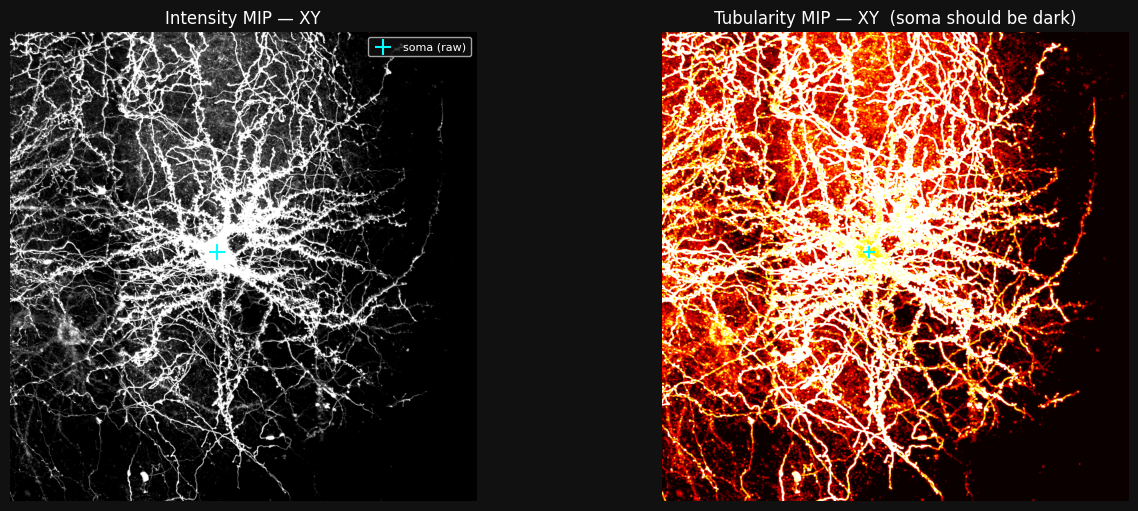

In [3]:
# ── Soma location visualization ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].imshow(stack.max(axis=0), cmap='gray', aspect='equal')
axes[0].scatter([soma_voxel[2]], [soma_voxel[1]], s=120,
                c='cyan', marker='+', linewidths=1.5, label='soma (raw)')
axes[0].set_title('Intensity MIP — XY')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].axis('off')

axes[1].imshow(T_combined.max(axis=0), cmap='hot', aspect='equal')
axes[1].scatter([soma_voxel[2]], [soma_voxel[1]], s=80,
                c='cyan', marker='+', linewidths=1.5)
axes[1].set_title('Tubularity MIP — XY  (soma should be dark)')
axes[1].axis('off')

plt.show()

In [4]:
# ── Step 7b · Soma Segmentation ───────────────────────────────
from skimage.filters import threshold_otsu
from scipy.ndimage import label as sp_label, binary_fill_holes
from scipy.ndimage import binary_opening, binary_closing, binary_erosion
from skimage.morphology import ball

# ── Bounding box crop ─────────────────────────────────────────
z0, y0, x0 = soma_voxel
m  = SOMA_SEARCH_RADIUS + 1
zs = slice(max(0, z0 - m), min(stack.shape[0], z0 + m))
ys = slice(max(0, y0 - m), min(stack.shape[1], y0 + m))
xs = slice(max(0, x0 - m), min(stack.shape[2], x0 + m))

crop   = stack[zs, ys, xs].astype(np.float32)
# T_combined은 blob 포함 → soma T>0 → 필터 오작동
# I_OOF_raw(순수 OOF)는 soma≈0 유지 → 올바른 tubularity 필터
t_crop = I_OOF_raw[zs, ys, xs]

# ── Spherical mask within crop ────────────────────────────────
cz = z0 - zs.start
cy = y0 - ys.start
cx = x0 - xs.start
ZZ, YY, XX = np.ogrid[:crop.shape[0], :crop.shape[1], :crop.shape[2]]
sphere = (ZZ - cz)**2 + (YY - cy)**2 + (XX - cx)**2 <= SOMA_SEARCH_RADIUS**2

# ── Local Otsu + tubularity mask ──────────────────────────────
soma_candidates = sphere & (t_crop < SOMA_MAX_TUBULARITY)
thresh   = threshold_otsu(crop[soma_candidates])
bin_crop = (crop > thresh) & soma_candidates
print(f'Otsu threshold : {thresh:.4f}  ({100 * bin_crop.sum() / sphere.sum():.1f}% of sphere)')

# ── Connected component containing the soma seed ──────────────
labeled, n_comp = sp_label(bin_crop)
lbl = labeled[cz, cy, cx]

if lbl == 0:
    print('WARNING: soma seed not in any component — try increasing SOMA_SEARCH_RADIUS '
          'or SOMA_MAX_TUBULARITY')
    soma_mask_crop = np.zeros_like(bin_crop)
else:
    soma_mask_crop = labeled == lbl
    print(f'Connected components in sphere : {n_comp}  → using component #{lbl}')

# ── Morphological refinement (가지 제거 + 표면 정리) ──────────
soma_mask_crop = binary_opening(soma_mask_crop, structure=ball(SOMA_OPEN_RADIUS_VX))
soma_mask_crop = binary_closing(soma_mask_crop, structure=ball(SOMA_CLOSE_RADIUS_VX))
soma_mask_crop = binary_erosion(soma_mask_crop, structure=ball(SOMA_ERODE_RADIUS_VX))
soma_mask_crop = binary_fill_holes(soma_mask_crop)

soma_mask = np.zeros(stack.shape, dtype=bool)
soma_mask[zs, ys, xs] = soma_mask_crop

# ── Morphological properties ──────────────────────────────────
soma_voxels_coords = np.argwhere(soma_mask)
n_soma_vox         = len(soma_voxels_coords)
soma_centroid_vox  = soma_voxels_coords.mean(axis=0) if n_soma_vox > 0 \
                     else np.array(soma_voxel, dtype=float)
soma_volume_um3    = n_soma_vox * voxel_iso ** 3
soma_equiv_r_um    = (3 * soma_volume_um3 / (4 * np.pi)) ** (1 / 3)

print(f'Soma voxels       : {n_soma_vox:,}')
print(f'Soma volume       : {soma_volume_um3:.1f} µm³')
print(f'Equivalent radius : {soma_equiv_r_um:.2f} µm')
print(f'Centroid (vox)    : {tuple(soma_centroid_vox.round(1))}')

Otsu threshold : 0.4590  (18.0% of sphere)
Connected components in sphere : 89  → using component #2
Soma voxels       : 115,117
Soma volume       : 4604.9 µm³
Equivalent radius : 10.32 µm
Centroid (vox)    : (266.5, 466.5, 438.4)


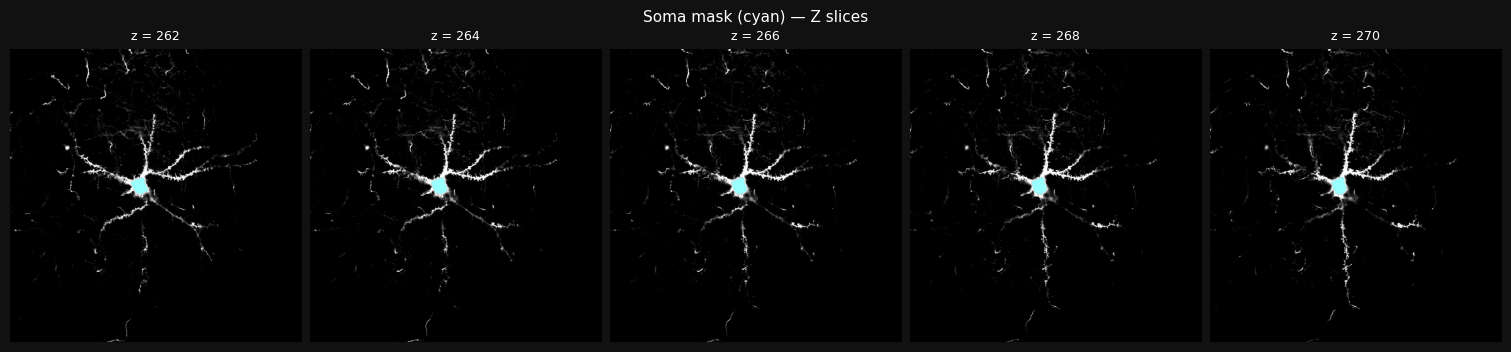

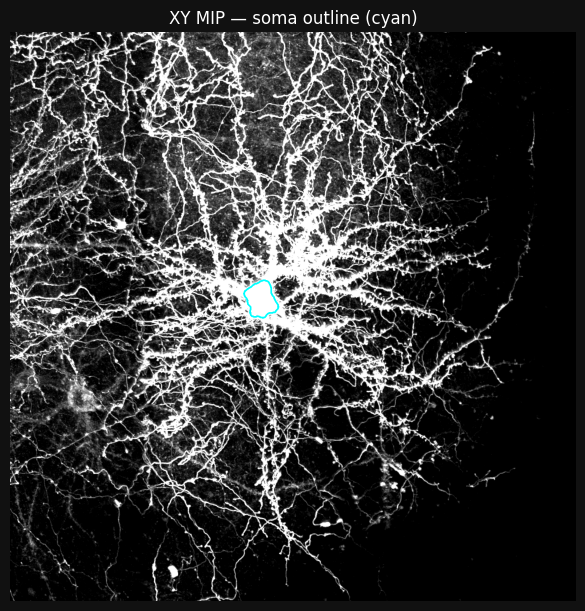

In [5]:
# ── Z-slice visualization ─────────────────────────────────────
z_mid   = int(soma_centroid_vox[0])
z_range = [z for z in range(z_mid - 4, z_mid + 5, 2) if 0 <= z < soma_mask.shape[0]]

fig, axes = plt.subplots(1, len(z_range), figsize=(3 * len(z_range), 3.5),
                         constrained_layout=True)
if len(z_range) == 1:
    axes = [axes]

for ax, z in zip(axes, z_range):
    ax.imshow(stack[z], cmap='gray', aspect='equal')
    overlay = np.zeros((*stack[z].shape, 4), dtype=np.float32)
    overlay[soma_mask[z], 1] = 1.0   # cyan
    overlay[soma_mask[z], 2] = 1.0
    overlay[soma_mask[z], 3] = 0.4
    ax.imshow(overlay, aspect='equal')
    ax.set_title(f'z = {z}', fontsize=9)
    ax.axis('off')

fig.suptitle('Soma mask (cyan) — Z slices', fontsize=11)
plt.show()

# XY MIP with soma outline
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.imshow(stack.max(axis=0), cmap='gray', aspect='equal')
ax.contour(soma_mask.max(axis=0), levels=[0.5], colors=['cyan'], linewidths=1.2)
ax.set_title('XY MIP — soma outline (cyan)')
ax.axis('off')
plt.show()

In [6]:
# ── 3D soma surface (marching cubes) ─────────────────────────
import plotly.graph_objects as go
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter

# Tight crop around soma
sc  = soma_voxels_coords
pad = 4
zs_v = slice(max(0, int(sc[:, 0].min()) - pad), int(sc[:, 0].max()) + pad + 1)
ys_v = slice(max(0, int(sc[:, 1].min()) - pad), int(sc[:, 1].max()) + pad + 1)
xs_v = slice(max(0, int(sc[:, 2].min()) - pad), int(sc[:, 2].max()) + pad + 1)

soma_crop   = soma_mask[zs_v, ys_v, xs_v].astype(np.float32)
soma_smooth = gaussian_filter(soma_crop, sigma=1.5)

verts, faces, _, _ = marching_cubes(soma_smooth, level=0.5,
                                     spacing=(voxel_iso, voxel_iso, voxel_iso))

origin_um = np.array([zs_v.start, ys_v.start, xs_v.start]) * voxel_iso
verts_um  = verts + origin_um   # (V, 3): z y x in µm

vx = verts_um[:, 2]   # X µm
vy = verts_um[:, 1]   # Y µm
vz = verts_um[:, 0]   # Z µm

# Per-vertex fluorescence intensity
vi = np.clip((verts_um / voxel_iso).astype(int), 0,
             np.array(stack.shape) - 1)
vert_intensity = stack[vi[:, 0], vi[:, 1], vi[:, 2]].astype(np.float32)
v_min, v_max   = vert_intensity.min(), vert_intensity.max()
vert_intensity = (vert_intensity - v_min) / (v_max - v_min + 1e-6)

cen_x = soma_centroid_vox[2] * voxel_iso
cen_y = soma_centroid_vox[1] * voxel_iso
cen_z = soma_centroid_vox[0] * voxel_iso

fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=vx, y=vy, z=vz,
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    intensity=vert_intensity,
    colorscale='Hot',
    cmin=0, cmax=1,
    opacity=0.75,
    flatshading=False,
    lighting=dict(ambient=0.4, diffuse=0.7, specular=0.3,
                  roughness=0.6, fresnel=0.2),
    lightposition=dict(x=1, y=1, z=2),
    showscale=False,
    name='Soma surface',
    showlegend=True,
))

fig.add_trace(go.Scatter3d(
    x=[cen_x], y=[cen_y], z=[cen_z],
    mode='markers',
    marker=dict(size=6, color='cyan', symbol='diamond'),
    name=f'Centroid  r_eq={soma_equiv_r_um:.1f} µm',
))

fig.update_layout(
    title=f'Soma 3D (actual shape)  —  V={soma_volume_um3:.0f} µm³  '
          f'r_eq={soma_equiv_r_um:.2f} µm',
    scene=dict(
        xaxis_title='X (µm)', yaxis_title='Y (µm)', zaxis_title='Z (µm)',
        bgcolor='#111111',
        aspectmode='data',
    ),
    paper_bgcolor='#111111', font_color='white',
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(x=0, y=1),
)
fig.show()
print(f'Surface mesh: {len(verts):,} vertices  {len(faces):,} faces')

Surface mesh: 18,744 vertices  37,484 faces


In [7]:
# ── Save soma checkpoint ──────────────────────────────────────
import json

np.savez_compressed(
    'output/soma.npz',
    soma_mask        = soma_mask,
    soma_centroid_vox= soma_centroid_vox,
    soma_equiv_r_um  = np.array(soma_equiv_r_um),
    voxel_iso        = np.array(voxel_iso),
    mesh_verts       = verts.astype(np.float32),
    mesh_faces       = faces.astype(np.int32),
)

# step2_morse.ipynb 호환 JSON
with open('output/soma.json', 'w') as f:
    json.dump({
        'centroid_vox': soma_centroid_vox.tolist(),
        'radius_um':    float(soma_equiv_r_um),
    }, f, indent=2)

print(f'Saved: output/soma.npz  verts={verts.shape}  faces={faces.shape}')
print(f'Saved: output/soma.json  centroid={soma_centroid_vox.round(1).tolist()}  r={soma_equiv_r_um:.2f} µm')

Saved: output/soma.npz  verts=(18744, 3)  faces=(37484, 3)
Saved: output/soma.json  centroid=[266.5, 466.5, 438.4]  r=10.32 µm


EDT: (89, 76, 71) crop  1.9s
Before: T_combined[soma] = 0.5943
After : T_anchored[soma] = 0.9373  (global max=1.0)
Anchor: 1.6s


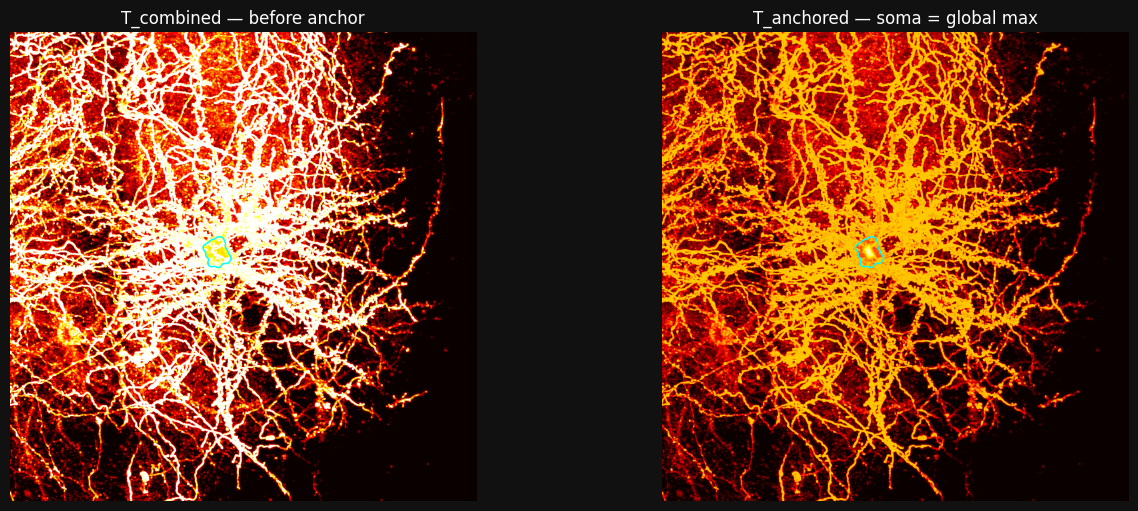

Saved: output/tubularity_anchored.npz  (121s)


In [8]:
# ── Soma Anchor: mask + distance transform → real soma shape ────
from scipy.ndimage import distance_transform_edt
import time

SOMA_ANCHOR_OFFSET = 0.5

# ── EDT: 전체 볼륨 아닌 soma bounding box만 ─────────────────
t0 = time.time()
coords = np.argwhere(soma_mask)
pad = 5
NZ, NY, NX = soma_mask.shape
z0b = max(0,  int(coords[:,0].min()) - pad)
y0b = max(0,  int(coords[:,1].min()) - pad)
x0b = max(0,  int(coords[:,2].min()) - pad)
z1b = min(NZ, int(coords[:,0].max()) + pad + 1)
y1b = min(NY, int(coords[:,1].max()) + pad + 1)
x1b = min(NX, int(coords[:,2].max()) + pad + 1)

mask_crop = soma_mask[z0b:z1b, y0b:y1b, x0b:x1b]
dist_crop = distance_transform_edt(mask_crop).astype(np.float32)
dist_crop /= (dist_crop.max() + 1e-8)   # [0,1]: 경계=0, 중심=1
print(f'EDT: {mask_crop.shape} crop  {time.time()-t0:.1f}s')

# ── anchor 삽입: bbox 영역만 처리 ────────────────────────────
# T_combined, I_OOF_raw, voxel_iso: cell-0 scope 재사용
t0 = time.time()
anchor_val = T_combined.max() + SOMA_ANCHOR_OFFSET
T_anchored = T_combined.copy()
T_crop     = T_anchored[z0b:z1b, y0b:y1b, x0b:x1b]
# soma 내부: EDT gradient로 완전 덮어쓰기 (OOF ring artifact 제거)
# soma 외부: T_combined 유지
T_crop[mask_crop] = (dist_crop * anchor_val)[mask_crop]
T_anchored[z0b:z1b, y0b:y1b, x0b:x1b] = T_crop
T_anchored /= T_anchored.max()

cz = int(soma_centroid_vox[0])
cy = int(soma_centroid_vox[1])
cx = int(soma_centroid_vox[2])
print(f'Before: T_combined[soma] = {T_combined[cz, cy, cx]:.4f}')
print(f'After : T_anchored[soma] = {T_anchored[cz, cy, cx]:.4f}  (global max=1.0)')
print(f'Anchor: {time.time()-t0:.1f}s')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].imshow(T_combined.max(axis=0), cmap='hot', vmin=0, vmax=1)
axes[0].contour(soma_mask.max(axis=0), levels=[0.5], colors=['cyan'], linewidths=1)
axes[0].set_title('T_combined — before anchor'); axes[0].axis('off')
axes[1].imshow(T_anchored.max(axis=0), cmap='hot', vmin=0, vmax=1)
axes[1].contour(soma_mask.max(axis=0), levels=[0.5], colors=['cyan'], linewidths=1)
axes[1].set_title('T_anchored — soma = global max'); axes[1].axis('off')
plt.show()

# ── 저장 ─────────────────────────────────────────────────────
t0 = time.time()
tub_rest = np.load('output/tubularity.npz')
np.savez_compressed('output/tubularity_anchored.npz',
    T_combined   = T_anchored,
    I_OOF_raw    = I_OOF_raw,
    orient_field = tub_rest['orient_field'],
    radius_map   = tub_rest['radius_map'],
    scale_idx    = tub_rest['scale_idx'],
    radii        = tub_rest['radii'],
    voxel_iso    = np.float32(voxel_iso),
    soma_mask    = soma_mask,
)
del tub_rest
print(f'Saved: output/tubularity_anchored.npz  ({time.time()-t0:.0f}s)')
